[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter12_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 12: Spectral analysis

*Lecture notebook (self-study chapter). Daniel Traian Pele, Bucharest University of Economic Studies.*

- Cycles, Fourier frequencies, the discrete Fourier transform and aliasing.
- Spectral densities of white noise and ARMA models; the periodogram and its properties; Fisher's test.
- Leakage and tapering; Daniell and Welch smoothing; chi-square confidence bands.
- Cycles in data: sunspots, US and Romanian GDP, the hourly electricity load of Romania.
- The spectral pole of long memory; filter gains; coherence and phase; a wavelet scalogram.
- Convention (Shumway and Stoffer 2017, ch. 4): frequency $\nu$ in cycles per observation, period $1/\nu$, $f(\nu) = \sum_h \gamma(h) e^{-2\pi i \nu h}$, periodogram $I(\nu_j) = |T^{-1/2}\sum_t x_t e^{-2\pi i \nu_j t}|^2$.
- References: Schuster (1898); Yule (1927); Fisher (1929); Welch (1967); Granger (1966); Torrence and Compo (1998).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_12'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `periodogram(x, taper)`: raw periodogram at the Fourier frequencies (optional Hann taper).
- `daniell(I, m)`: average of $2m+1$ neighbouring ordinates; `chi2_band(f, df)`: 95% band; `welch(x, n)`: Welch estimate.
- `arma_spectrum(nu, phi, theta)`: theoretical ARMA spectrum; `fisher_g(I)`: Fisher's test; `gph_spec(x)`: GPH estimate of $d$.
- `morlet_cwt(x, periods)`: Morlet wavelet power; data loaders for sunspots, GDP and the electricity load.

In [5]:
from scipy import signal
from statsmodels.tsa.filters.hp_filter import hpfilter
SEED = 2026
RO_GDP = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
GDP_END = '2019-12-31'
BC_BAND = (6, 32)
HP_LAMBDA = 1600
LOAD_FILE = 'ch4_ro_load_hourly.csv'
LOAD_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_04/ch4_ro_load_hourly.csv'
BW = 0.65
AR2 = (1.5, -0.75)
DFT_EXAMPLE = [4.0, 2.0, 0.0, 2.0]
HERE = "."


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def periodogram(x, taper=False):
    """Periodogram I(nu_j) = |d(nu_j)|^2, d(nu_j) = T^(-1/2) sum_t x_t exp(-2 pi i nu_j t), at the Fourier
    frequencies nu_j = j / T, j = 1..[T/2] (mean removed). With taper=True a Hann (cosine bell) taper is applied
    and rescaled so that the total power is unchanged."""
    x = np.asarray(x, float)
    x = x - x.mean()
    T = len(x)
    if taper:
        w = 0.5 * (1 - np.cos(2 * np.pi * (np.arange(T) + 0.5) / T))
        x = x * w / np.sqrt(np.mean(w ** 2))
    I = np.abs(np.fft.fft(x)) ** 2 / T
    j = np.arange(1, T // 2 + 1)
    return j / T, I[j]


def daniell(I, m):
    """Daniell smoother: the average of the 2m + 1 periodogram ordinates around each frequency (reflected at the
    ends); approximately chi-square with df = 2(2m + 1) degrees of freedom."""
    if m == 0:
        return np.asarray(I, float)
    k = np.ones(2 * m + 1) / (2 * m + 1)
    return np.convolve(np.pad(np.asarray(I, float), m, mode='reflect'), k, mode='valid')


def chi2_band(fhat, df, level=0.95):
    """Approximate confidence interval for f(nu): [df fhat / chi2_df(1 - a/2), df fhat / chi2_df(a/2)]."""
    a = 1 - level
    return df * fhat / stats.chi2.ppf(1 - a / 2, df), df * fhat / stats.chi2.ppf(a / 2, df)


def welch(x, nperseg):
    """Welch estimate (Hann windows, 50% overlap), rescaled to the convention f(nu) = sum_h gamma(h) e^(-2 pi i nu h)."""
    nu, P = signal.welch(np.asarray(x, float) - np.mean(x), fs=1.0, window='hann', nperseg=nperseg)
    return nu[1:], P[1:] / 2


def arma_spectrum(nu, phi=(), theta=(), sigma2=1.0):
    """Spectral density of an ARMA(p,q): sigma^2 |theta(e^(-2 pi i nu))|^2 / |phi(e^(-2 pi i nu))|^2."""
    z = np.exp(-2j * np.pi * np.asarray(nu, float))
    num = np.ones_like(z) + sum(t * z ** (k + 1) for k, t in enumerate(theta))
    den = 1 - sum(p * z ** (k + 1) for k, p in enumerate(phi))
    return sigma2 * np.abs(num) ** 2 / np.abs(den) ** 2


def simulate_arma(phi, theta, T, seed=SEED, burn=500):
    rng = np.random.default_rng(seed)
    e = rng.standard_normal(T + burn)
    x = np.zeros(T + burn)
    for t in range(T + burn):
        x[t] = e[t] + sum(th * e[t - k - 1] for k, th in enumerate(theta) if t - k - 1 >= 0) \
            + sum(p * x[t - k - 1] for k, p in enumerate(phi) if t - k - 1 >= 0)
    return x[burn:]


def fisher_g(I):
    """Fisher's (1929) g test of a hidden periodicity: g = max I_j / sum I_j over j = 1..m (nu_j < 1/2), with the
    exact p-value P(g > x) = sum_k (-1)^(k-1) C(m, k) (1 - kx)^(m-1), k <= 1/x."""
    I = np.asarray(I, float)
    m = len(I)
    g = I.max() / I.sum()
    from math import comb
    p = sum((-1) ** (k - 1) * comb(m, k) * (1 - k * g) ** (m - 1) for k in range(1, int(1 / g) + 1))
    return {'g': float(g), 'm': int(m), 'p': float(min(max(p, 0.0), 1.0)), 'j': int(np.argmax(I) + 1)}


def gph_spec(x, m=None):
    """GPH (Geweke and Porter-Hudak 1983): OLS slope of log I(nu_j) on -log(4 sin^2(pi nu_j)), j = 1..m, is d;
    standard error pi / sqrt(24 m)."""
    nu, I = periodogram(x)
    m = m or int(np.floor(len(x) ** BW))
    X = -np.log(4 * np.sin(np.pi * nu[:m]) ** 2)
    b = np.polyfit(X, np.log(I[:m]), 1)
    return {'d': float(b[0]), 'c': float(b[1]), 'se': float(np.pi / np.sqrt(24 * m)), 'm': int(m),
            'nu_m': float(nu[m - 1])}


def morlet_cwt(x, periods, w0=6.0):
    """Continuous wavelet transform with a Morlet wavelet (Torrence and Compo 1998), computed by FFT;
    returns the wavelet power |W(s, t)|^2 / variance for the given Fourier periods (in observations)."""
    x = np.asarray(x, float)
    x = (x - x.mean()) / x.std()
    T = len(x)
    n = 1 << int(np.ceil(np.log2(2 * T)))
    xf = np.fft.fft(x, n)
    om = 2 * np.pi * np.fft.fftfreq(n)
    fourier_factor = 4 * np.pi / (w0 + np.sqrt(2 + w0 ** 2))
    P = np.zeros((len(periods), T))
    for i, per in enumerate(periods):
        s = per / fourier_factor
        psi = np.pi ** -0.25 * np.sqrt(2 * np.pi * s) * np.exp(-0.5 * (s * om - w0) ** 2) * (om > 0)
        P[i] = np.abs(np.fft.ifft(xf * psi)[:T]) ** 2
    return P


def sunspots():
    """Yearly mean sunspot number 1700-2008 (Wolf / SILSO series as shipped with statsmodels)."""
    s = load_statsmodels('sunspots')
    s.index = s.index.year
    return s


def gdp_growth(end=GDP_END):
    """Quarterly growth of real GDP, 100 x log difference: United States (FRED GDPC1) and Romania (Eurostat)."""
    us = read_fred('GDPC1').loc[:end]
    ro = read_eurostat(*RO_GDP).loc[:end]
    return {'US': (100 * np.log(us)).diff().dropna(), 'RO': (100 * np.log(ro)).diff().dropna(),
            'US_level': 100 * np.log(us), 'RO_level': 100 * np.log(ro)}


def hp_cycle(level, lam=HP_LAMBDA):
    cyc, trend = hpfilter(level, lamb=lam)
    return cyc


def load_hourly():
    """Hourly electricity load of Romania, MW (ENTSO-E extract of Chapter 4), on a regular UTC hourly grid."""
    s = None
    local = [os.path.join(HERE, '..', 'Ch_04', LOAD_FILE)] + [os.path.join(d, 'Quantlets', 'Ch_04', LOAD_FILE)
                                                                for d in ('.', '..', '../..', '../../..')]
    for src in [p for p in local if os.path.exists(p)] + [LOAD_RAW]:
        try:
            s = pd.read_csv(src, index_col=0, parse_dates=True).iloc[:, 0]
            break
        except Exception:
            continue
    s = s[~s.index.duplicated()].sort_index()
    s = s.reindex(pd.date_range(s.index[0], s.index[-1], freq='h')).interpolate()
    return s.rename('load_MW')

## 1. Cycles, the DFT and aliasing

- Worked examples of the slides; two cycles plus noise; a 4-month cycle seen quarterly.

DFT of (4, 2, 0, 2): {'x': [4.0, 2.0, 0.0, 2.0], 'mean': 2.0, 'I': [0.0, 4.0, 0.0, 4.0], 'var': 2.0, 'sumI': 8.0}
AR(2) peak: {'phi1': 1.5, 'phi2': -0.75, 'cos': 0.875, 'nu': 0.08043062325516624, 'period': 12.433075357721634, 'fpeak': 63.99999999999994, 'f0': 16.0}


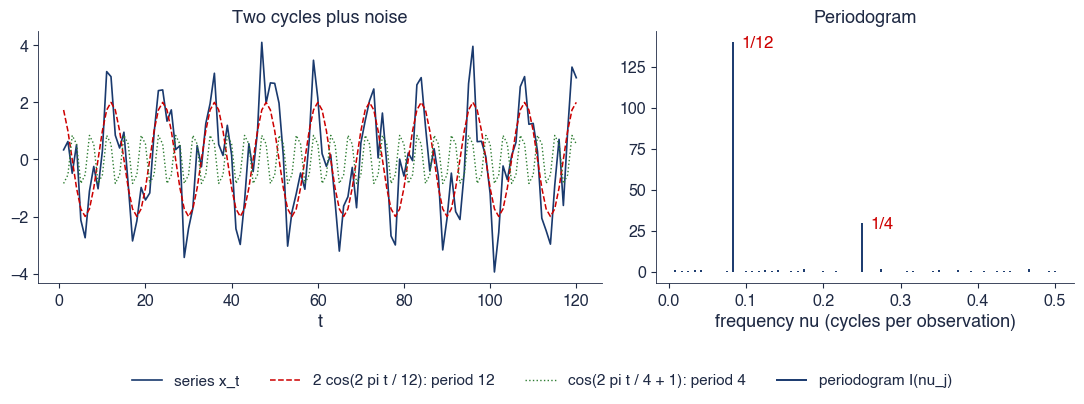

{'T': 120, 'I12': 139.73545067726224, 'I4': 29.608318348743794, 'share': 0.8498915819518182, 'var': 3.3153446162566422, 'theory12': 120.0, 'theory4': 30.0}


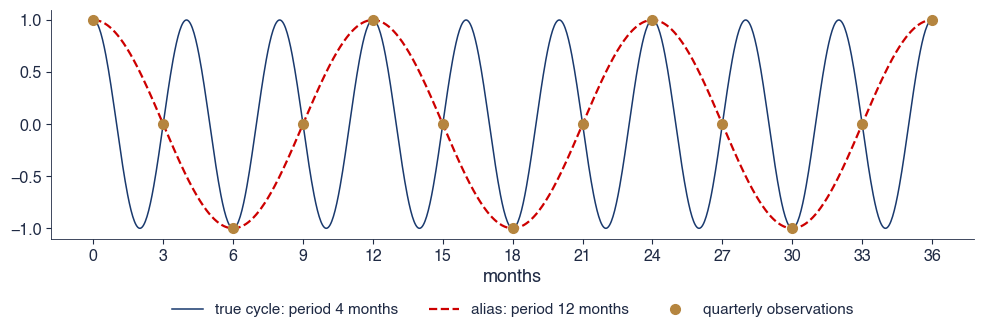

[0. 4. 0. 4.]


In [6]:
def worked_examples():
    """Numbers of the worked examples: DFT of (4, 2, 0, 2); AR(1) and MA(1) spectra; the AR(2) peak; aliasing of a
    4-month cycle observed quarterly; a Daniell confidence interval."""
    x = np.array(DFT_EXAMPLE)
    T = len(x)
    y = x - x.mean()
    d = np.fft.fft(y) / np.sqrt(T)
    I = np.abs(d) ** 2
    phi1, phi2 = AR2
    c = phi1 * (phi2 - 1) / (4 * phi2)
    nu_star = float(np.arccos(c) / (2 * np.pi))
    L = 5
    lo, hi = chi2_band(1.0, 2 * L)
    nu_true = 1 / 4                         # cycles per month: a 4-month cycle
    nu_q = nu_true * 3                      # cycles per quarter when observed every 3 months
    alias = abs(nu_q - round(nu_q))
    return {'dft': {'x': x.tolist(), 'mean': float(x.mean()), 'I': I.tolist(), 'var': float(np.mean(y ** 2)),
                    'sumI': float(I[1:].sum())},
            'ar1': {'phi': 0.6, 'f0': float(arma_spectrum(0, [0.6])), 'f5': float(arma_spectrum(0.5, [0.6]))},
            'ma1': {'theta': 0.5, 'f0': float(arma_spectrum(0, [], [0.5])), 'f5': float(arma_spectrum(0.5, [], [0.5]))},
            'ar2': {'phi1': phi1, 'phi2': phi2, 'cos': float(c), 'nu': nu_star, 'period': 1 / nu_star,
                    'fpeak': float(arma_spectrum(nu_star, AR2)), 'f0': float(arma_spectrum(0, AR2))},
            'ci': {'L': L, 'df': 2 * L, 'lo': float(lo), 'hi': float(hi),
                   'q_lo': float(stats.chi2.ppf(0.025, 2 * L)), 'q_hi': float(stats.chi2.ppf(0.975, 2 * L))},
            'alias': {'nu_month': nu_true, 'nu_quarter': nu_q, 'alias': float(alias), 'period_q': float(1 / alias),
                      'period_m': float(3 / alias)}}


def fig_fourier(save_it=True):
    """A series built from two cosines plus noise, its components and its periodogram (spikes at 1/12 and 1/4)."""
    rng = np.random.default_rng(SEED)
    T = 120
    t = np.arange(1, T + 1)
    c1 = 2.0 * np.cos(2 * np.pi * t / 12)
    c2 = 1.0 * np.cos(2 * np.pi * t / 4 + 1.0)
    x = c1 + c2 + rng.normal(0, 0.7, T)
    nu, I = periodogram(x)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1.35, 1]})
    ax = axes[0]
    ax.plot(t, x, color=st.MainBlue, lw=1.2, label='series x_t')
    ax.plot(t, c1, color=st.IDAred, lw=1.1, ls='--', label='2 cos(2 pi t / 12): period 12')
    ax.plot(t, c2, color=st.Forest, lw=1.0, ls=':', label='cos(2 pi t / 4 + 1): period 4')
    ax.set_xlabel('t')
    ax.set_title('Two cycles plus noise')
    ax = axes[1]
    ax.vlines(nu, 0, I, color=st.MainBlue, lw=1.4, label='periodogram I(nu_j)')
    ax.set_xlabel('frequency nu (cycles per observation)')
    ax.set_title('Periodogram')
    for v, lab in ((1 / 12, '1/12'), (1 / 4, '1/4')):
        ax.annotate(lab, (v, I[np.argmin(abs(nu - v))]), textcoords='offset points', xytext=(6, -4), color=st.IDAred)
    st.fig_legend_bottom(fig, ncol=4, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_fourier', save_it)
    j1, j2 = np.argmin(abs(nu - 1 / 12)), np.argmin(abs(nu - 1 / 4))
    var = np.mean((x - x.mean()) ** 2)
    return {'T': T, 'I12': float(I[j1]), 'I4': float(I[j2]), 'share': float((I[j1] + I[j2]) / I.sum()),
            'var': float(var), 'theory12': float(2.0 ** 2 * T / 4), 'theory4': float(1.0 ** 2 * T / 4)}


def fig_aliasing(save_it=True):
    """Aliasing: a 4-month cycle observed once a quarter looks like a 12-month cycle."""
    tm = np.linspace(0, 36, 1000)
    tq = np.arange(0, 37, 3)
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(tm, np.cos(2 * np.pi * tm / 4), color=st.MainBlue, lw=1.1, label='true cycle: period 4 months')
    ax.plot(tm, np.cos(2 * np.pi * tm / 12), color=st.IDAred, lw=1.6, ls='--', label='alias: period 12 months')
    ax.plot(tq, np.cos(2 * np.pi * tq / 4), 'o', ms=7, color=st.Amber, label='quarterly observations')
    ax.set_xlabel('months')
    ax.set_xticks(np.arange(0, 37, 3))
    st.legend_outside_bottom(ax, ncol=3)
    fig.tight_layout()
    save('tsa_ch12_aliasing', save_it)
    return {'nyquist_q': 0.5, 'match': bool(np.allclose(np.cos(2 * np.pi * tq / 4), np.cos(2 * np.pi * tq / 12)))}


ex = worked_examples()
print('DFT of (4, 2, 0, 2):', ex['dft'])
print('AR(2) peak:', ex['ar2'])
print(fig_fourier(save_it=False))
fig_aliasing(save_it=False)
# check: the FFT gives the same periodogram as the hand computation
print(np.abs(np.fft.fft([2, 0, -2, 0])) ** 2 / 4)

## 2. Spectral densities of ARMA models

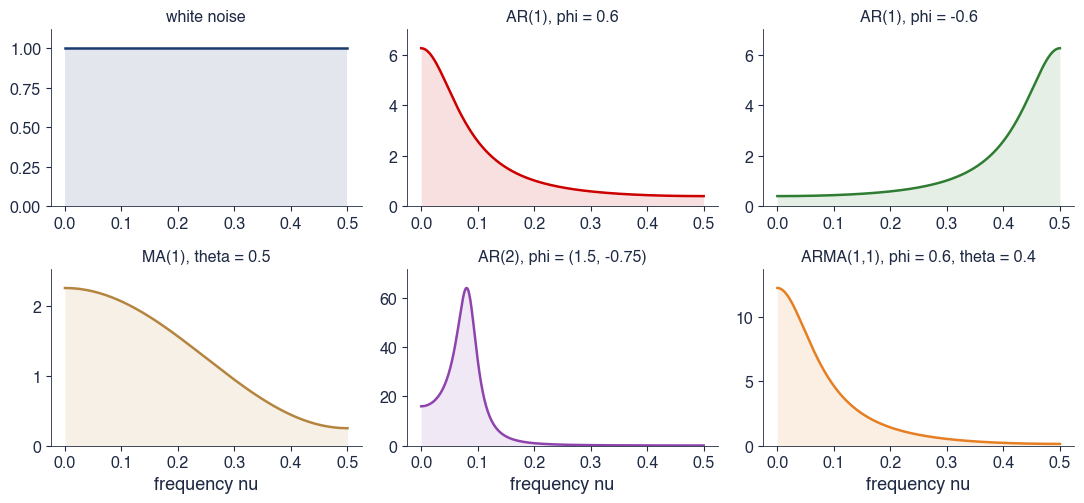

                                       f0    f05    var  argmax
white noise                         1.000  1.000  1.000    0.00
AR(1), phi = 0.6                    6.250  0.391  1.562    0.00
AR(1), phi = -0.6                   0.391  6.250  1.562    0.50
MA(1), theta = 0.5                  2.250  0.250  1.250    0.00
AR(2), phi = (1.5, -0.75)          16.000  0.095  8.615    0.08
ARMA(1,1), phi = 0.6, theta = 0.4  12.250  0.141  2.562    0.00


In [7]:
SPECTRA = [('white noise', (), ()), ('AR(1), phi = 0.6', (0.6,), ()), ('AR(1), phi = -0.6', (-0.6,), ()), ('MA(1), theta = 0.5', (), (0.5,)), ('AR(2), phi = (1.5, -0.75)', (1.5, -0.75), ()), ('ARMA(1,1), phi = 0.6, theta = 0.4', (0.6,), (0.4,))]


def fig_spectra(save_it=True):
    """Theoretical spectral densities (sigma^2 = 1) of six models, with their variance (area under f)."""
    nu = np.linspace(0, 0.5, 501)
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.2))
    out = {}
    for i, (ax, (lab, phi, theta)) in enumerate(zip(axes.flat, SPECTRA)):
        f = arma_spectrum(nu, phi, theta)
        ax.plot(nu, f, color=st.PALETTE[i], lw=1.8, label=lab)
        ax.fill_between(nu, 0, f, color=st.PALETTE[i], alpha=0.12, lw=0)
        ax.set_title(lab, fontsize=11.5)
        ax.set_ylim(0, f.max() * 1.12)
        if i >= 3:
            ax.set_xlabel('frequency nu')
        var = 2 * np.trapezoid(f, nu)
        out[lab] = {'f0': float(f[0]), 'f05': float(f[-1]), 'var': float(var), 'argmax': float(nu[np.argmax(f)])}
    fig.tight_layout()
    save('tsa_ch12_spectra', save_it)
    return out


sp = fig_spectra(save_it=False)
print(pd.DataFrame(sp).T.round(3))

## 3. The periodogram: sunspots and white noise

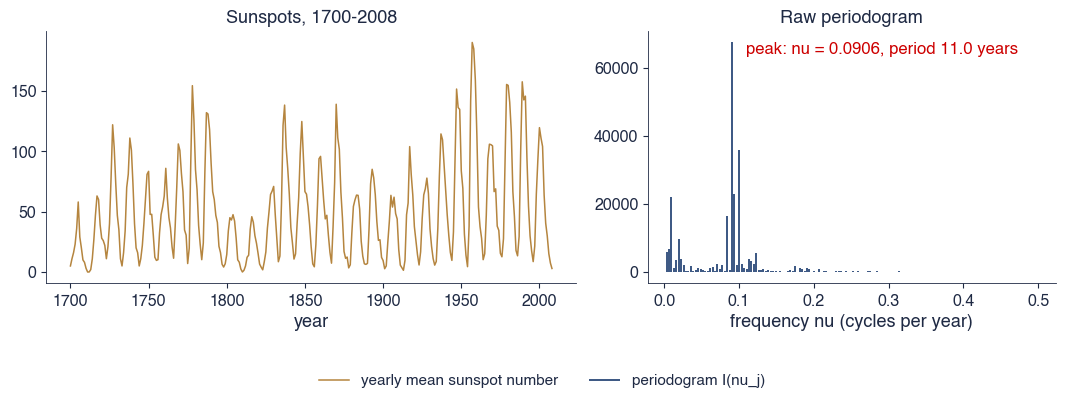

peak period: 11.04 years; Fisher g: {'g': 0.2678747683932111, 'm': 154, 'p': 2.9449844622049826e-19, 'j': 28}


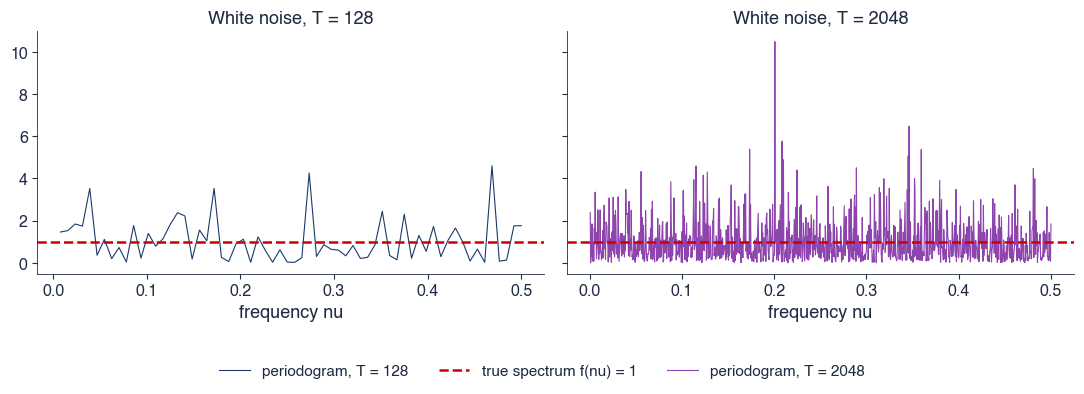

{'128': {'mean': 1.0317601342545224, 'sd': 1.0286835706822064, 'max': 4.598019660817684, 'q95': 3.4151138412136715}, '2048': {'mean': 1.0071351655982919, 'sd': 0.9990663400655314, 'max': 10.488862772317196, 'q95': 3.0122629908442677}, 'chi2_q95': 2.99573227355399}


In [8]:
def fig_sunspots(save_it=True):
    """Yearly sunspot numbers 1700-2008 and their raw periodogram against the period in years."""
    s = sunspots()
    nu, I = periodogram(s.values)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1.3, 1]})
    axes[0].plot(s.index, s.values, color=st.Amber, lw=1.1, label='yearly mean sunspot number')
    axes[0].set_xlabel('year')
    axes[0].set_title(f'Sunspots, {s.index[0]}-{s.index[-1]}')
    ax = axes[1]
    ax.vlines(nu, 0, I, color=st.MainBlue, lw=1.2, label='periodogram I(nu_j)')
    j = int(np.argmax(I))
    ax.annotate(f'peak: nu = {nu[j]:.4f}, period {1 / nu[j]:.1f} years', (nu[j], I[j]), textcoords='offset points',
                xytext=(10, -8), color=st.IDAred)
    ax.set_xlabel('frequency nu (cycles per year)')
    ax.set_title('Raw periodogram')
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_sunspots', save_it)
    band = (1 / nu >= 9) & (1 / nu <= 13)
    order = np.argsort(I)[::-1][:3]
    return {'T': int(len(s)), 'y0': int(s.index[0]), 'y1': int(s.index[-1]), 'j': j + 1, 'nu': float(nu[j]),
            'period': float(1 / nu[j]), 'share_band': float(I[band].sum() / I.sum()),
            'top3': [float(1 / nu[k]) for k in order], 'fisher': fisher_g(I[nu < 0.5]),
            'mean': float(s.mean()), 'max': float(s.max()), 'max_year': int(s.idxmax())}


def fig_inconsistency(save_it=True):
    """Periodogram of Gaussian white noise (sigma^2 = 1) for T = 128 and T = 2048: it does not settle down."""
    rng = np.random.default_rng(SEED)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), sharey=True)
    out = {}
    for ax, T, c in zip(axes, (128, 2048), (st.MainBlue, st.Purple)):
        x = rng.standard_normal(T)
        nu, I = periodogram(x)
        ax.plot(nu, I, color=c, lw=0.8, label=f'periodogram, T = {T}' if T == 128 else 'periodogram, T = 2048')
        ax.axhline(1.0, color=st.IDAred, lw=1.8, ls='--', label='true spectrum f(nu) = 1' if T == 128 else '_')
        ax.set_title(f'White noise, T = {T}')
        ax.set_xlabel('frequency nu')
        I0 = I[nu < 0.5]
        out[str(T)] = {'mean': float(I0.mean()), 'sd': float(I0.std()), 'max': float(I0.max()),
                       'q95': float(np.quantile(I0, 0.95))}
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_inconsistency', save_it)
    out['chi2_q95'] = float(stats.chi2.ppf(0.95, 2) / 2)
    return out


sun = fig_sunspots(save_it=False)
print('peak period:', round(sun['period'], 2), 'years; Fisher g:', sun['fisher'])
print(fig_inconsistency(save_it=False))

## 4. Leakage, smoothing and confidence bands

- Try other values of `m` in `daniell` and other segment lengths in `welch`.

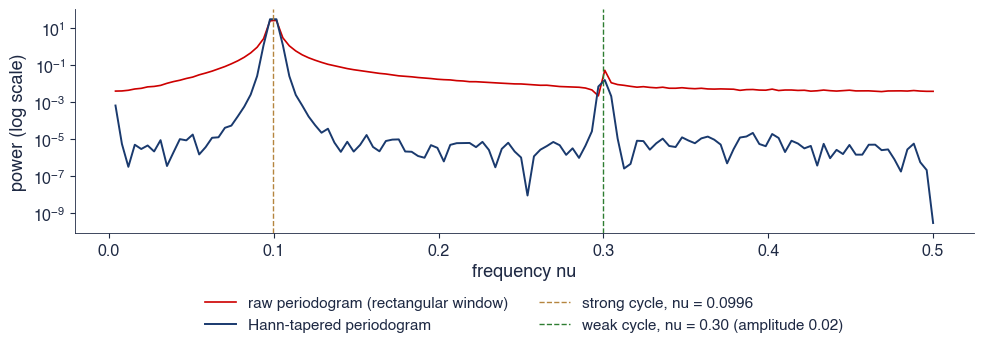

{'T': 256, 'nu1': 0.099609375, 'nu2': 0.3, 'a2': 0.02, 'raw_at2': 0.053650492429238444, 'tap_at2': 0.01600096483398309, 'raw_bg': 0.006957656037685677, 'tap_bg': 3.7831352543191387e-06, 'raw_ratio': 7.711000966222555, 'tap_ratio': 4229.551353130997}


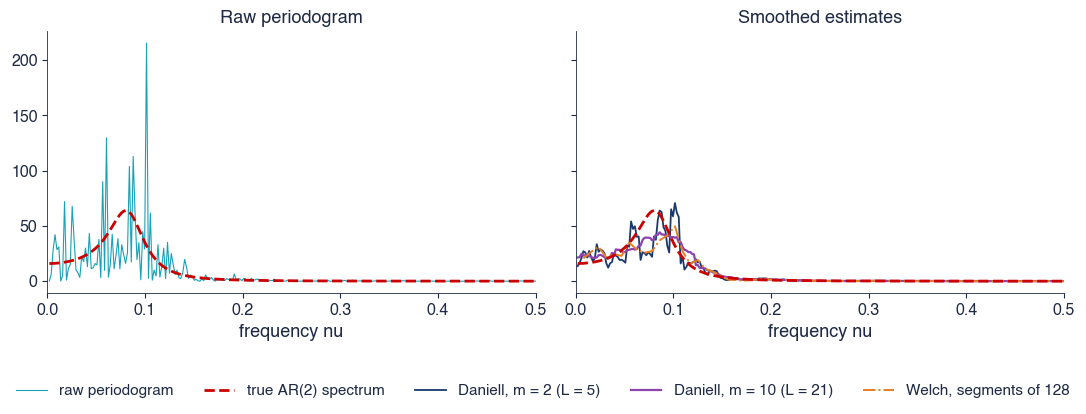

{'T': 512, 'true_peak': 0.080078125, 'raw_peak': 0.1015625, 'mse_raw': 1.8649041009655118, 'd2': {'peak': 0.1015625, 'mse': 0.24655830053167888, 'fpeak': 70.7940265752674}, 'd10': {'peak': 0.0859375, 'mse': 0.09189630230833493, 'fpeak': 44.292422835416744}, 'welch': {'peak': 0.1015625, 'mse': 0.24239682616358812, 'K': 7}, 'ftrue_peak': 63.9859320846633}


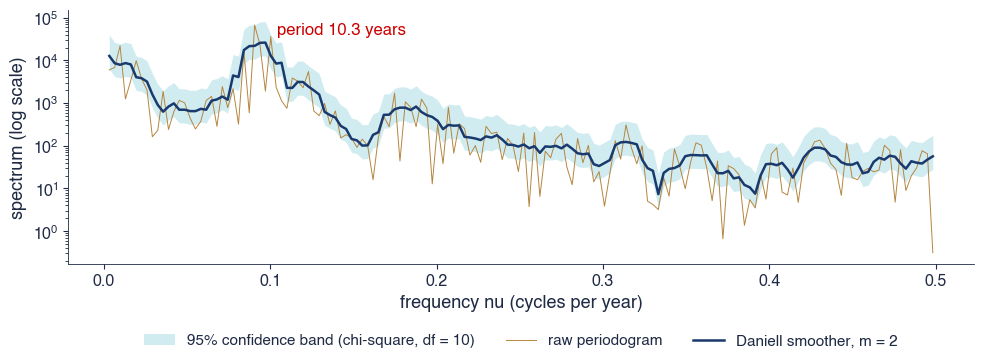

{'m': 2, 'L': 5, 'df': 10, 'B': 0.016181229773462782, 'nu': 0.0970873786407767, 'period': 10.3, 'f': 26095.07864930071, 'lo': 12739.76112317951, 'hi': 80367.40809202986, 'ratio_hi': 3.079791755836824, 'ratio_lo': 0.48820550780447286, 'f018': 780.3124680099911, 'hi018': 2403.199905953856}


In [9]:
def fig_leakage(save_it=True):
    """A strong cosine between two Fourier frequencies plus a weak one: raw and Hann-tapered periodograms (log scale)."""
    rng = np.random.default_rng(SEED)
    T = 256
    t = np.arange(T)
    nu1, nu2, a2 = 25.5 / T, 0.30, 0.02
    x = np.cos(2 * np.pi * nu1 * t) + a2 * np.cos(2 * np.pi * nu2 * t) + rng.normal(0, 0.002, T)
    nu, I = periodogram(x)
    _, It = periodogram(x, taper=True)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.semilogy(nu, I, color=st.IDAred, lw=1.2, label='raw periodogram (rectangular window)')
    ax.semilogy(nu, It, color=st.MainBlue, lw=1.4, label='Hann-tapered periodogram')
    ax.axvline(nu1, color=st.Amber, lw=1, ls='--', label=f'strong cycle, nu = {nu1:.4f}')
    ax.axvline(nu2, color=st.Forest, lw=1, ls='--', label=f'weak cycle, nu = {nu2:.2f} (amplitude {a2})')
    ax.set_xlabel('frequency nu')
    ax.set_ylabel('power (log scale)')
    st.legend_outside_bottom(ax, ncol=2)
    fig.tight_layout()
    save('tsa_ch12_leakage', save_it)
    k = np.argmin(abs(nu - nu2))
    near = (abs(nu - nu2) > 3 / T) & (abs(nu - nu2) < 10 / T)
    return {'T': T, 'nu1': nu1, 'nu2': nu2, 'a2': a2, 'raw_at2': float(I[k]), 'tap_at2': float(It[k]),
            'raw_bg': float(np.median(I[near])), 'tap_bg': float(np.median(It[near])),
            'raw_ratio': float(I[k] / np.median(I[near])), 'tap_ratio': float(It[k] / np.median(It[near]))}


def fig_smoothing(save_it=True):
    """AR(2) with a pseudo-cycle, T = 512: raw periodogram, Daniell (m = 2 and m = 10) and Welch against the truth."""
    T = 512
    x = simulate_arma(AR2, (), T)
    nu, I = periodogram(x)
    f = arma_spectrum(nu, AR2)
    est = {'Daniell, m = 2 (L = 5)': daniell(I, 2), 'Daniell, m = 10 (L = 21)': daniell(I, 10)}
    nw, fw = welch(x, 128)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
    axes[0].plot(nu, I, color=st.Teal, lw=0.8, label='raw periodogram')
    axes[0].set_title('Raw periodogram')
    axes[1].plot(nu, est['Daniell, m = 2 (L = 5)'], color=st.MainBlue, lw=1.3, label='Daniell, m = 2 (L = 5)')
    axes[1].plot(nu, est['Daniell, m = 10 (L = 21)'], color=st.Purple, lw=1.6, label='Daniell, m = 10 (L = 21)')
    axes[1].plot(nw, fw, color=st.Orange, lw=1.4, ls='-.', label='Welch, segments of 128')
    axes[1].set_title('Smoothed estimates')
    for ax in axes:
        ax.plot(nu, f, color=st.IDAred, lw=2, ls='--', label='true AR(2) spectrum' if ax is axes[0] else '_')
        ax.set_xlabel('frequency nu')
        ax.set_xlim(0, 0.5)
    st.fig_legend_bottom(fig, ncol=5, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_smoothing', save_it)
    out = {'T': T, 'true_peak': float(nu[np.argmax(f)]), 'raw_peak': float(nu[np.argmax(I)])}
    lf = np.log(f)
    out['mse_raw'] = float(np.mean((np.log(I) - lf) ** 2))
    for k, (lab, v) in zip(('d2', 'd10'), est.items()):
        out[k] = {'peak': float(nu[np.argmax(v)]), 'mse': float(np.mean((np.log(v) - lf) ** 2)),
                  'fpeak': float(v.max())}
    fwt = arma_spectrum(nw, AR2)
    out['welch'] = {'peak': float(nw[np.argmax(fw)]), 'mse': float(np.mean((np.log(fw) - np.log(fwt)) ** 2)),
                    'K': int((T - 128) // 64 + 1)}
    out['ftrue_peak'] = float(f.max())
    return out


def fig_sunspot_ci(save_it=True):
    """Daniell-smoothed periodogram of the sunspots (m = 2, df = 10) with a 95% chi-square band, log scale."""
    s = sunspots()
    nu, I = periodogram(s.values)
    m = 2
    fh = daniell(I, m)
    df = 2 * (2 * m + 1)
    lo, hi = chi2_band(fh, df)
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.fill_between(nu, lo, hi, color=st.Teal, alpha=0.2, lw=0, label='95% confidence band (chi-square, df = 10)')
    ax.semilogy(nu, I, color=st.Amber, lw=0.7, label='raw periodogram')
    ax.semilogy(nu, fh, color=st.MainBlue, lw=1.8, label='Daniell smoother, m = 2')
    j = int(np.argmax(fh))
    ax.annotate(f'period {1 / nu[j]:.1f} years', (nu[j], fh[j]), textcoords='offset points', xytext=(8, 6),
                color=st.IDAred)
    ax.set_xlabel('frequency nu (cycles per year)')
    ax.set_ylabel('spectrum (log scale)')
    st.legend_outside_bottom(ax, ncol=3)
    fig.tight_layout()
    save('tsa_ch12_sunspot_ci', save_it)
    j2 = np.argmin(abs(nu - 0.18))
    return {'m': m, 'L': 2 * m + 1, 'df': df, 'B': float((2 * m + 1) / len(s)), 'nu': float(nu[j]),
            'period': float(1 / nu[j]), 'f': float(fh[j]), 'lo': float(lo[j]), 'hi': float(hi[j]),
            'ratio_hi': float(hi[j] / fh[j]), 'ratio_lo': float(lo[j] / fh[j]), 'f018': float(fh[j2]),
            'hi018': float(hi[j2])}


print(fig_leakage(save_it=False))
print(fig_smoothing(save_it=False))
print(fig_sunspot_ci(save_it=False))

## 5. Business cycles: US and Romanian GDP

- Samples end in 2019 Q4: the 2020 collapse would dominate the periodogram.

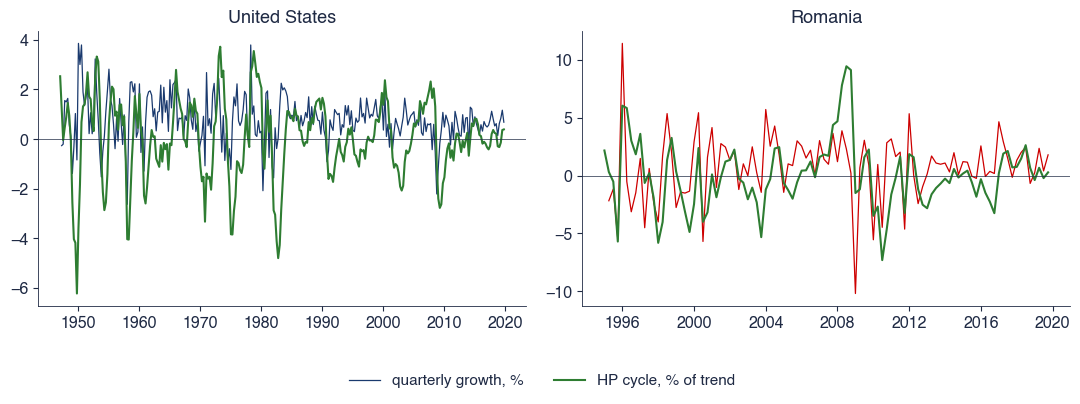

{'US': {'T': 291, 'start': '1947-04-01', 'end': '2019-10-01', 'mean': 0.7777578376048548, 'sd': 0.9281825749309943, 'cyc_sd': 1.583351773642391}, 'RO': {'T': 99, 'start': '1995-04-01', 'end': '2019-10-01', 'mean': 0.7310178875962212, 'sd': 2.8534392755105085, 'cyc_sd': 2.87537912691897}}


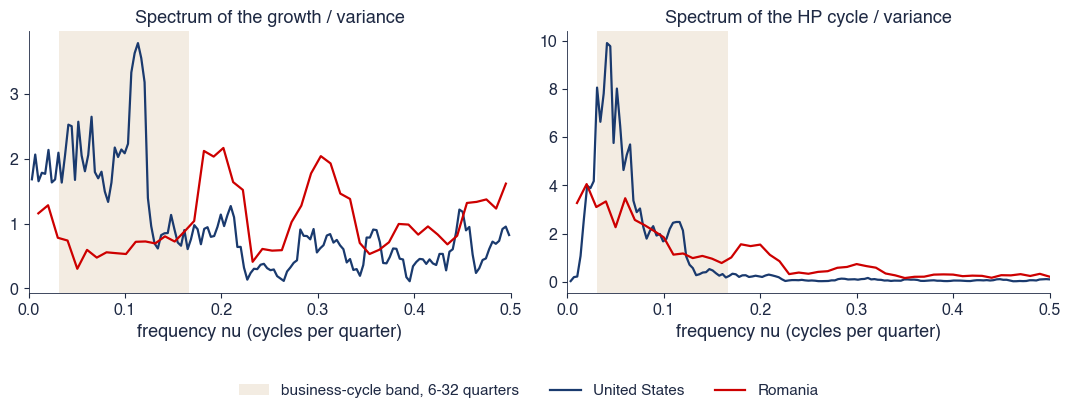

             share_bc  share_low  peak_period      T
US.growth       0.488      0.110        8.818  291.0
RO.growth       0.156      0.062        4.950   99.0
US.HP cycle     0.797      0.140       24.333  292.0
RO.HP cycle     0.490      0.166       50.000  100.0


In [10]:
def fig_gdp_series(save_it=True):
    """US and Romanian real GDP: quarterly growth and HP cycle (lambda = 1600), up to 2019 Q4."""
    G = gdp_growth()
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    out = {}
    for ax, k, c in zip(axes, ('US', 'RO'), (st.MainBlue, st.IDAred)):
        cyc = hp_cycle(G[k + '_level'])
        ax.plot(G[k].index, G[k].values, color=c, lw=0.9, label='quarterly growth, %' if k == 'US' else '_')
        ax.plot(cyc.index, cyc.values, color=st.Forest, lw=1.5, label='HP cycle, % of trend' if k == 'US' else '_')
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.set_title('United States' if k == 'US' else 'Romania')
        out[k] = {'T': int(len(G[k])), 'start': str(G[k].index[0].date()), 'end': str(G[k].index[-1].date()),
                  'mean': float(G[k].mean()), 'sd': float(G[k].std()), 'cyc_sd': float(cyc.std())}
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_gdp_series', save_it)
    return out


def fig_gdp_spectra(save_it=True):
    """Smoothed spectra (Daniell, m = 2) of GDP growth and of the HP cycle, as a share of the variance, with the
    business-cycle band of 6-32 quarters."""
    G = gdp_growth()
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    out = {}
    lo_nu, hi_nu = 1 / BC_BAND[1], 1 / BC_BAND[0]
    for ax, kind in zip(axes, ('growth', 'HP cycle')):
        ax.axvspan(lo_nu, hi_nu, color=st.Amber, alpha=0.15, lw=0, label='business-cycle band, 6-32 quarters' if kind == 'growth' else '_')
        for k, c in (('US', st.MainBlue), ('RO', st.IDAred)):
            x = G[k] if kind == 'growth' else hp_cycle(G[k + '_level'])
            nu, I = periodogram(x.values)
            fh = daniell(I, 2)
            ax.plot(nu, fh / np.mean((x - x.mean()) ** 2), color=c, lw=1.6,
                    label=('United States' if k == 'US' else 'Romania') if kind == 'growth' else '_')
            band = (nu >= lo_nu) & (nu <= hi_nu)
            j = int(np.argmax(fh))
            out[f'{k}.{kind}'] = {'share_bc': float(I[band].sum() / I.sum()), 'share_low': float(I[nu < lo_nu].sum() / I.sum()),
                                  'peak_period': float(1 / nu[j]), 'T': int(len(x))}
        ax.set_title(f'Spectrum of the {kind} / variance')
        ax.set_xlabel('frequency nu (cycles per quarter)')
        ax.set_xlim(0, 0.5)
    st.fig_legend_bottom(fig, ncol=3, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_gdp_spectra', save_it)
    return out


print(fig_gdp_series(save_it=False))
print(pd.DataFrame(fig_gdp_spectra(save_it=False)).T.round(3))

## 6. The daily and weekly rhythm of electricity load

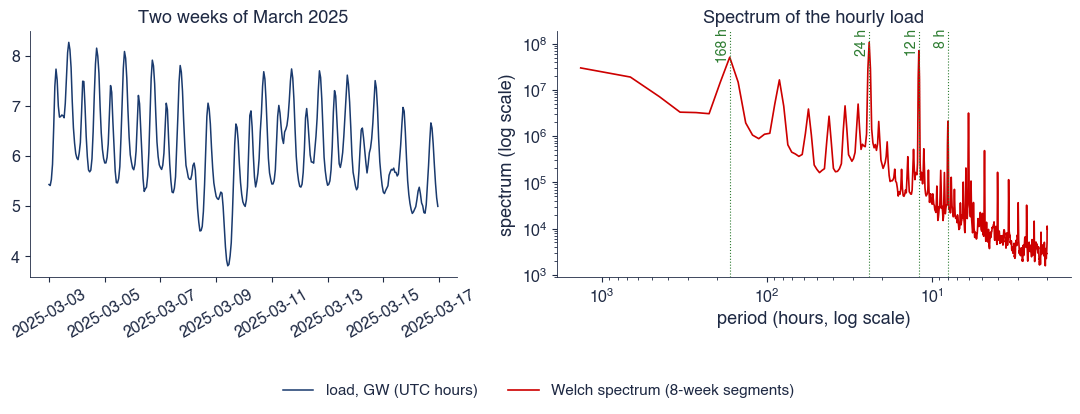

{'T': 39408, 'start': '2022-01-01', 'end': '2026-06-30', 'mean': 6176.326361525578, 'share_daily': 0.3366590431385674, 'share_weekly': 0.15650003318137062, 'share_long': 0.3287942811595922, 'top': [24.0, 12.0, 7881.599999999999, 4378.666666666667, 167.6936170212766, 84.02558635394456]}


In [11]:
def fig_load(save_it=True):
    """Hourly electricity load of Romania: two weeks of data and the Welch spectrum against the period in hours."""
    s = load_hourly()
    x = s.values
    nw, fw = welch(x, 24 * 7 * 8)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw={'width_ratios': [1, 1.2]})
    w = s.loc['2025-03-03':'2025-03-16 23:00']
    axes[0].plot(w.index, w.values / 1000, color=st.MainBlue, lw=1.1, label='load, GW (UTC hours)')
    axes[0].set_title('Two weeks of March 2025')
    axes[0].tick_params(axis='x', labelrotation=30)
    ax = axes[1]
    ax.loglog(1 / nw, fw, color=st.IDAred, lw=1.2, label='Welch spectrum (8-week segments)')
    for p, lab in ((168, '168 h'), (24, '24 h'), (12, '12 h'), (8, '8 h')):
        ax.axvline(p, color=st.Forest, lw=0.8, ls=':')
        ax.text(p, ax.get_ylim()[1] if False else fw.max() * 2, lab, rotation=90, va='top', ha='right', color=st.Forest, fontsize=10)
    ax.set_xlabel('period (hours, log scale)')
    ax.set_ylabel('spectrum (log scale)')
    ax.set_title('Spectrum of the hourly load')
    ax.invert_xaxis()
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_load', save_it)
    nu, I = periodogram(x)
    T = len(x)
    tot = I.sum()

    def share(periods, width=2):
        idx = set()
        for p in periods:
            j = int(round(T / p))
            idx.update(range(max(j - width, 1) - 1, min(j + width, len(I) - 1)))
        return float(I[sorted(idx)].sum() / tot)
    daily = share([24 / k for k in range(1, 7)])
    weekly = share([168 / k for k in range(1, 7)] + [168 * 2])
    order = np.argsort(I)[::-1]
    top = []
    for k in order:
        p = 1 / nu[k]
        if all(abs(p - q) / q > 0.05 for q in top):
            top.append(float(p))
        if len(top) == 6:
            break
    return {'T': int(T), 'start': str(s.index[0].date()), 'end': str(s.index[-1].date()), 'mean': float(s.mean()),
            'share_daily': daily, 'share_weekly': weekly, 'share_long': float(I[1 / nu > 24 * 30].sum() / tot),
            'top': top}


print(fig_load(save_it=False))

## 7. Long memory: the pole at zero (Chapter 8)

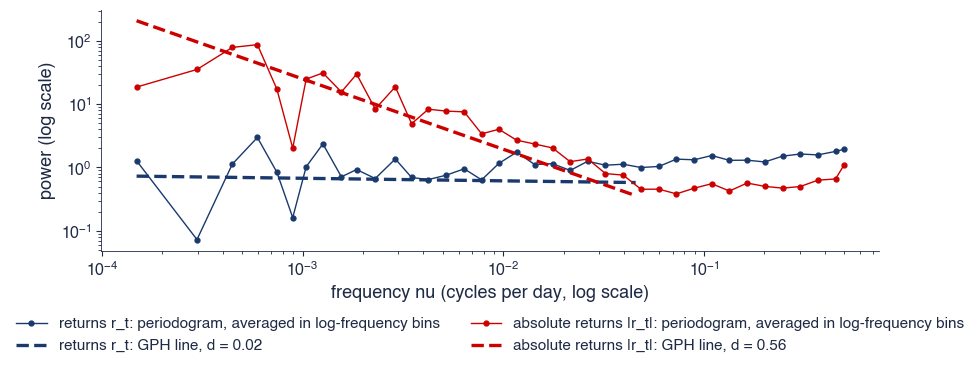

{'r': {'d': 0.02036576145701219, 'c': -0.6000100871708346, 'se': 0.03659949256123093, 'm': 307, 'nu_m': 0.04572535001489425}, 'abs': {'d': 0.556101464521471, 'c': -2.4166224876129783, 'se': 0.03659949256123093, 'm': 307, 'nu_m': 0.04572535001489425}, 'T': 6714}


In [12]:
def fig_long_memory(save_it=True):
    """Log-log periodogram of daily S&P 500 returns and absolute returns, with the GPH line on the lowest frequencies."""
    r = log_returns('sp500').values
    S = [('returns r_t', r, st.MainBlue), ('absolute returns |r_t|', np.abs(r), st.IDAred)]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    for lab, x, c in S:
        nu, I = periodogram(x)
        edges = np.geomspace(nu[0], 0.5, 41)                 # 40 bins of equal width in log frequency
        k = np.digitize(nu, edges)
        nb = np.array([np.exp(np.mean(np.log(nu[k == b]))) for b in np.unique(k)])
        Ib = np.array([I[k == b].mean() for b in np.unique(k)])
        ax.loglog(nb, Ib, 'o-', color=c, lw=1.0, ms=3.5, label=f'{lab}: periodogram, averaged in log-frequency bins')
        g = gph_spec(x)
        m = g['m']
        xx = nu[:m]
        ax.loglog(xx, np.exp(g['c'] - g['d'] * np.log(4 * np.sin(np.pi * xx) ** 2)), color=c, lw=2.4, ls='--',
                  label=f"{lab}: GPH line, d = {g['d']:.2f}")
        out['abs' if 'abs' in lab else 'r'] = g
    ax.set_xlabel('frequency nu (cycles per day, log scale)')
    ax.set_ylabel('power (log scale)')
    st.legend_outside_bottom(ax, ncol=2)
    fig.tight_layout()
    save('tsa_ch12_long_memory', save_it)
    out['T'] = int(len(r))
    return out


print(fig_long_memory(save_it=False))

## 8. Linear filters: differencing and the HP filter

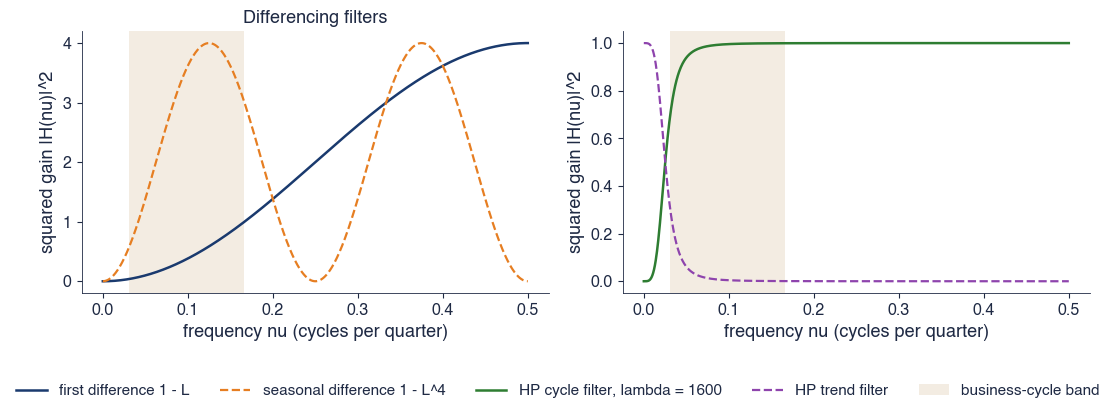

{'d1_40': 0.024623318809724546, 'd1_4': 1.9999999999999996, 'hp_8': 0.9981819279299443, 'hp_32': 0.7026389197350632, 'hp_40': 0.492409627247017, 'hp_half_nu': 0.025, 'hp_half_period': 40.0}


In [13]:
def hp_gain(nu, lam=HP_LAMBDA):
    """Squared gain of the HP cycle filter: 4 lam (1 - cos w)^2 / (1 + 4 lam (1 - cos w)^2), w = 2 pi nu."""
    a = 4 * lam * (1 - np.cos(2 * np.pi * nu)) ** 2
    return a / (1 + a)


def fig_filters(save_it=True):
    """Squared gains of the first difference, the seasonal difference (s = 4) and the HP filter (lambda = 1600)."""
    nu = np.linspace(0, 0.5, 1001)
    g1 = 4 * np.sin(np.pi * nu) ** 2
    g4 = 4 * np.sin(4 * np.pi * nu) ** 2
    gh = hp_gain(nu)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    axes[0].plot(nu, g1, color=st.MainBlue, lw=1.8, label='first difference 1 - L')
    axes[0].plot(nu, g4, color=st.Orange, lw=1.6, ls='--', label='seasonal difference 1 - L^4')
    axes[0].set_title('Differencing filters')
    axes[1].plot(nu, gh, color=st.Forest, lw=1.8, label='HP cycle filter, lambda = 1600')
    axes[1].plot(nu, 1 - gh, color=st.Purple, lw=1.6, ls='--', label='HP trend filter')
    for ax in axes:
        ax.axvspan(1 / BC_BAND[1], 1 / BC_BAND[0], color=st.Amber, alpha=0.15, lw=0,
                   label='business-cycle band' if ax is axes[1] else '_')
        ax.set_xlabel('frequency nu (cycles per quarter)')
        ax.set_ylabel('squared gain |H(nu)|^2')
    st.fig_legend_bottom(fig, ncol=5, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_filters', save_it)
    half = float(nu[np.argmin(abs(gh - 0.5))])
    return {'d1_40': float(4 * np.sin(np.pi / 40) ** 2), 'd1_4': float(4 * np.sin(np.pi / 4) ** 2),
            'hp_8': float(hp_gain(1 / 8)), 'hp_32': float(hp_gain(1 / 32)), 'hp_40': float(hp_gain(1 / 40)),
            'hp_half_nu': half, 'hp_half_period': 1 / half}


print(fig_filters(save_it=False))

## 9. Two series: coherence and phase

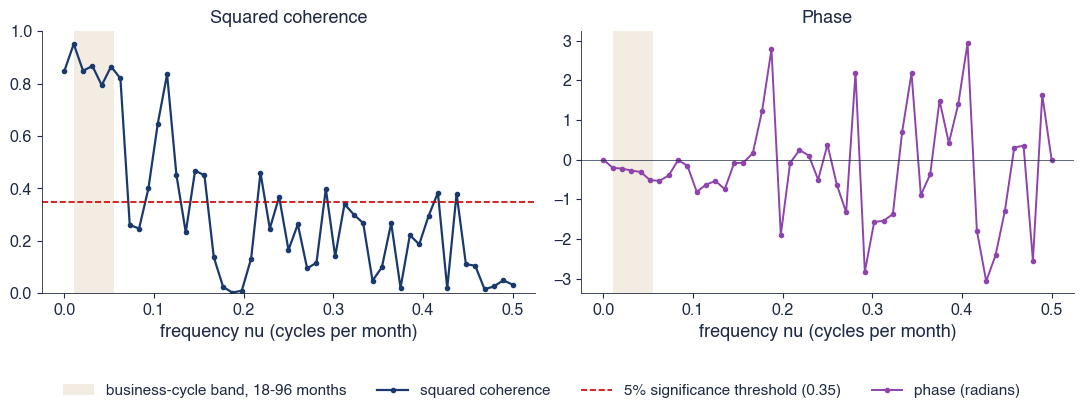

{'T': 863, 'start': '1948-02-01', 'end': '2019-12-01', 'K': 8, 'thr': 0.3481636551311609, 'coh_bc': 0.8651575757060431, 'coh_bc_max': 0.9510682606781842, 'coh_hi': 0.17443123148227635, 'phase48': -0.22605626186917777, 'nu48': 0.020833333333333332, 'lag48': 1.7269426316810679, 'corr0': 0.4875328745403427}


In [14]:
def fig_coherence(save_it=True):
    """Squared coherence and phase of US industrial production growth and the fall in unemployment (monthly,
    1948-2019), Welch segments of 96 months without overlap."""
    F = read_fred(['INDPRO', 'UNRATE']).loc['1948-01-01':'2019-12-31'].dropna()
    ip = 100 * np.log(F['INDPRO']).diff()
    du = -F['UNRATE'].diff()
    d = pd.concat([ip, du], axis=1).dropna()
    x, y = d.iloc[:, 0].values, d.iloc[:, 1].values
    n = 96
    nu, C = signal.coherence(x, y, fs=1.0, window='hann', nperseg=n, noverlap=0)
    _, Pxy = signal.csd(x, y, fs=1.0, window='hann', nperseg=n, noverlap=0)
    ph = np.angle(Pxy)
    K = len(x) // n
    thr = 1 - 0.05 ** (1 / (K - 1))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    band = (nu >= 1 / 96) & (nu <= 1 / 18)
    for ax in axes:
        ax.axvspan(1 / 96, 1 / 18, color=st.Amber, alpha=0.15, lw=0, label='business-cycle band, 18-96 months' if ax is axes[0] else '_')
    axes[0].plot(nu, C, color=st.MainBlue, lw=1.6, marker='o', ms=3, label='squared coherence')
    axes[0].axhline(thr, color=st.IDAred, lw=1.2, ls='--', label=f'5% significance threshold ({thr:.2f})')
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Squared coherence')
    axes[1].plot(nu, ph, color=st.Purple, lw=1.4, marker='o', ms=3, label='phase (radians)')
    axes[1].axhline(0, color=st.DarkText, lw=0.5)
    axes[1].set_title('Phase')
    for ax in axes:
        ax.set_xlabel('frequency nu (cycles per month)')
    st.fig_legend_bottom(fig, ncol=4, y=0.03)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch12_coherence', save_it)
    j = np.argmin(abs(nu - 1 / 48))
    lag48 = float(-ph[j] / (2 * np.pi * nu[j]))      # > 0: the fall in unemployment lags production
    hi = (nu > 1 / 6)
    return {'T': int(len(x)), 'start': str(d.index[0].date()), 'end': str(d.index[-1].date()), 'K': int(K),
            'thr': float(thr), 'coh_bc': float(C[band].mean()), 'coh_bc_max': float(C[band].max()),
            'coh_hi': float(C[hi].mean()), 'phase48': float(ph[j]), 'nu48': float(nu[j]), 'lag48': lag48,
            'corr0': float(np.corrcoef(x, y)[0, 1])}


print(fig_coherence(save_it=False))

## 10. A pointer: wavelets

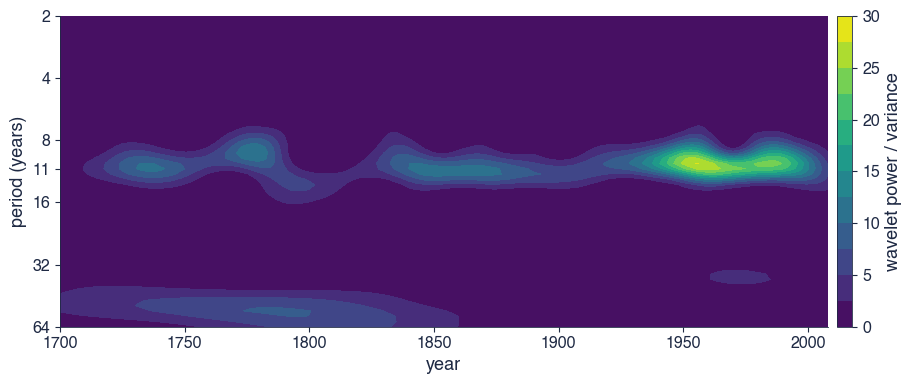

{'p11_mean': 9.67422601324491, 'weak_1795_1830': 1.9797777717173395, 'all': 5.743065673657035, 'max_year': 1956}


In [15]:
def fig_wavelet(save_it=True):
    """Morlet wavelet power of the yearly sunspot numbers: how the strength and length of the cycle change in time."""
    s = sunspots()
    periods = np.geomspace(2, 64, 60)
    P = morlet_cwt(s.values, periods)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    cs = ax.contourf(s.index, periods, P, levels=12, cmap='viridis')
    ax.set_yscale('log', base=2)
    ax.set_yticks([2, 4, 8, 11, 16, 32, 64])
    ax.set_yticklabels(['2', '4', '8', '11', '16', '32', '64'])
    ax.invert_yaxis()
    ax.set_ylabel('period (years)')
    ax.set_xlabel('year')
    fig.colorbar(cs, ax=ax, label='wavelet power / variance', pad=0.01)
    fig.tight_layout()
    save('tsa_ch12_wavelet', save_it)
    k = np.argmin(abs(periods - 11))
    band = (periods >= 8) & (periods <= 14)
    pw = P[band].mean(axis=0)
    yrs = s.index.values
    weak = (yrs >= 1795) & (yrs <= 1830)
    return {'p11_mean': float(P[k].mean()), 'weak_1795_1830': float(pw[weak].mean()), 'all': float(pw.mean()),
            'max_year': int(yrs[np.argmax(pw)])}


print(fig_wavelet(save_it=False))

## Exercises for self-study

1. Compute by hand the periodogram of $x = (1, -1, 1, -1)$; check it with `np.fft.fft`.
2. Plot the spectrum of an AR(2) with $\phi = (1.0, -0.5)$; find the peak period with the formula of the slides.
3. Apply the Daniell smoother with $m = 1, 2, 5, 10$ to the sunspot periodogram; which $m$ would you report?
4. Repeat Section 5 for another EU country (Eurostat key `Q.CLV10_MEUR.SCA.B1GQ.<country code>`).
5. Compute the coherence between Romanian and euro-area GDP growth (`EA20`); interpret the business-cycle band.